Tujuan: Membangun model machine learning untuk memprediksi jumlah kalori yang terbakar
berdasarkan fitur demografi dan fisiologis (usia, jenis kelamin, tinggi, berat,
durasi olahraga, denyut jantung, suhu tubuh).

Business Question: Apakah model dapat memprediksi kalori dengan MAE ≤ 75 kkal dan R² ≥ 0.75?

#Import Library

In [1]:
!pip install xgboost lightgbm -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings('ignore')
# Set style visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 2. BUSINESS UNDERSTANDING

##Latar Belakang:
Penentuan jumlah kalori yang terbakar saat olahraga sangat penting untuk perencanaan diet
dan program kebugaran. Namun, alat pengukur kalori tidak selalu tersedia. Dengan memanfaatkan
data demografi (usia, gender, tinggi, berat) dan data real-time (durasi, denyut jantung,
suhu tubuh), dapat membangun model prediktif yang akurat.

##Tujuan:
Membangun model machine learning yang mampu memprediksi kalori yang terbakar (Calories)
dengan error minimal dan akurasi tinggi.

##Hipotesis:
- Fitur seperti durasi, denyut jantung, dan berat badan memiliki pengaruh signifikan
  terhadap jumlah kalori yang terbakar.
- Model ensemble (Random Forest, XGBoost) akan mengungguli regresi linear sederhana.

##Manfaat:
- Membantu pengguna memantau pengeluaran kalori tanpa alat khusus.
- Mendukung personalisasi program latihan dan diet.

# Data Understanding


In [3]:
df = pd.read_csv('cleaned_calories.csv')
print("Dataset shape:", df.shape)
print("\n5 data teratas:")
print(df.head())
print("\nInformasi dataset:")
print(df.info())
print("\nStatistik deskriptif:")
print(df.describe())

# Cek missing value
print("\nMissing values per kolom:")
print(df.isnull().sum())

# Cek duplikat
duplicates = df.duplicated().sum()
print(f"\nJumlah baris duplikat: {duplicates}")

Dataset shape: (15000, 9)

5 data teratas:
    User_ID  Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  \
0  14733363    male   68   190.0    94.0      29.0       105.0       40.8   
1  14861698  female   20   166.0    60.0      14.0        94.0       40.3   
2  11179863    male   69   179.0    79.0       5.0        88.0       38.7   
3  16180408  female   34   179.0    71.0      13.0       100.0       40.5   
4  17771927  female   27   154.0    58.0      10.0        81.0       39.8   

   Calories  
0     231.0  
1      66.0  
2      26.0  
3      71.0  
4      35.0  

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  flo

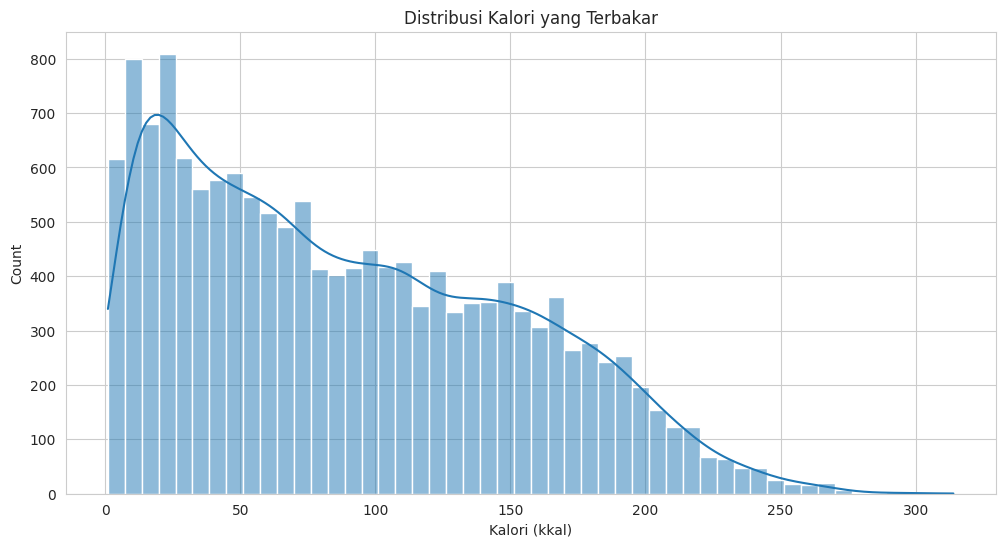

In [4]:
# Visualisasi distribusi target
plt.figure()
sns.histplot(df['Calories'], bins=50, kde=True)
plt.title('Distribusi Kalori yang Terbakar')
plt.xlabel('Kalori (kkal)')
plt.show()

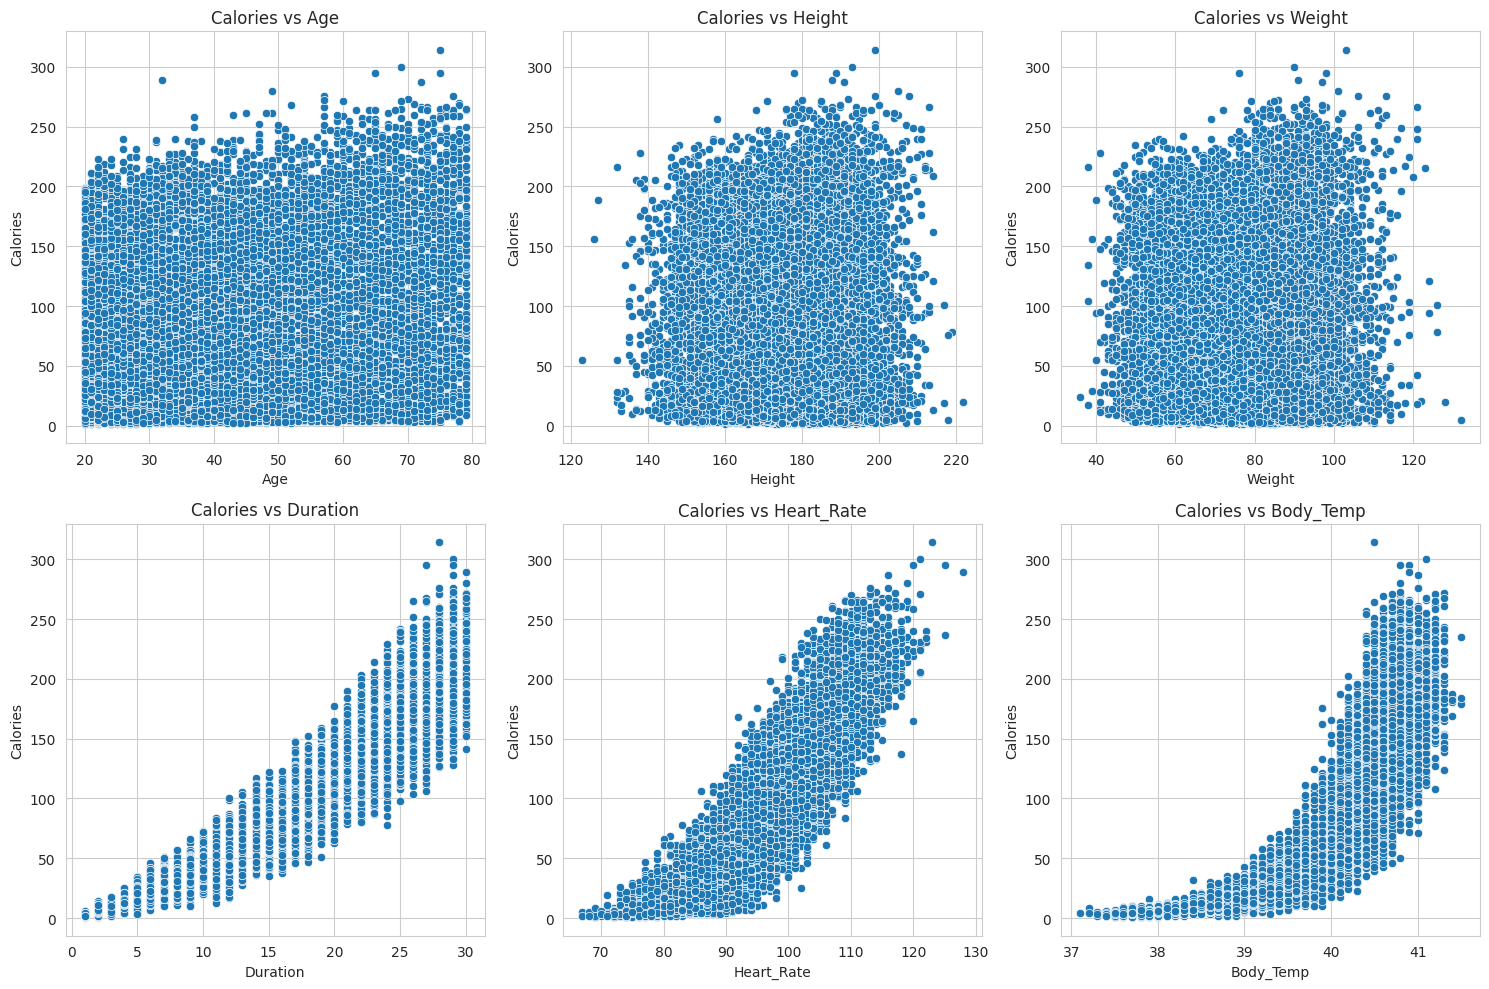

In [5]:
# Visualisasi hubungan dengan variabel kontinu
numeric_cols = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(numeric_cols[:-1]):
    sns.scatterplot(data=df, x=col, y='Calories', ax=axes[i])
    axes[i].set_title(f'Calories vs {col}')
plt.tight_layout()
plt.show()

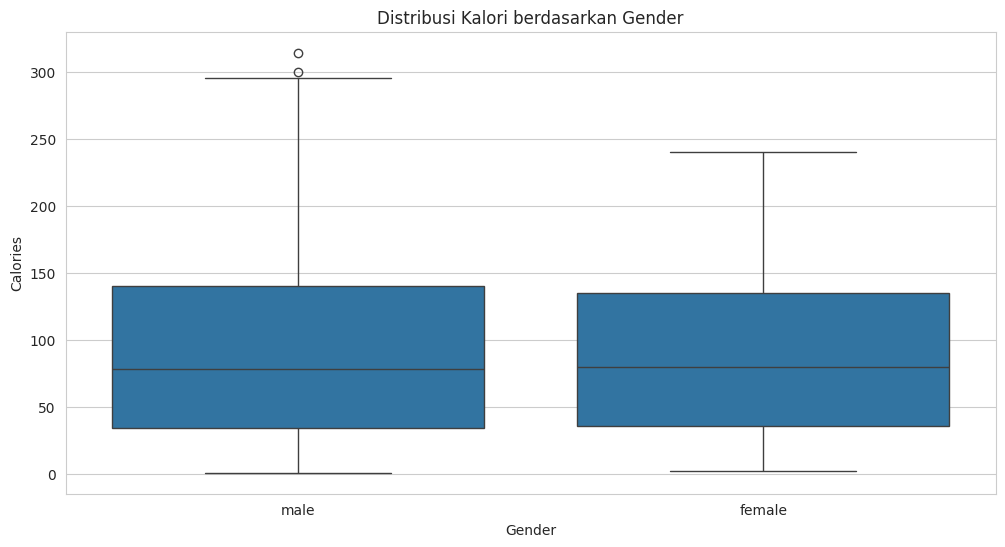

In [6]:
# Boxplot berdasarkan Gender
plt.figure()
sns.boxplot(data=df, x='Gender', y='Calories')
plt.title('Distribusi Kalori berdasarkan Gender')
plt.show()

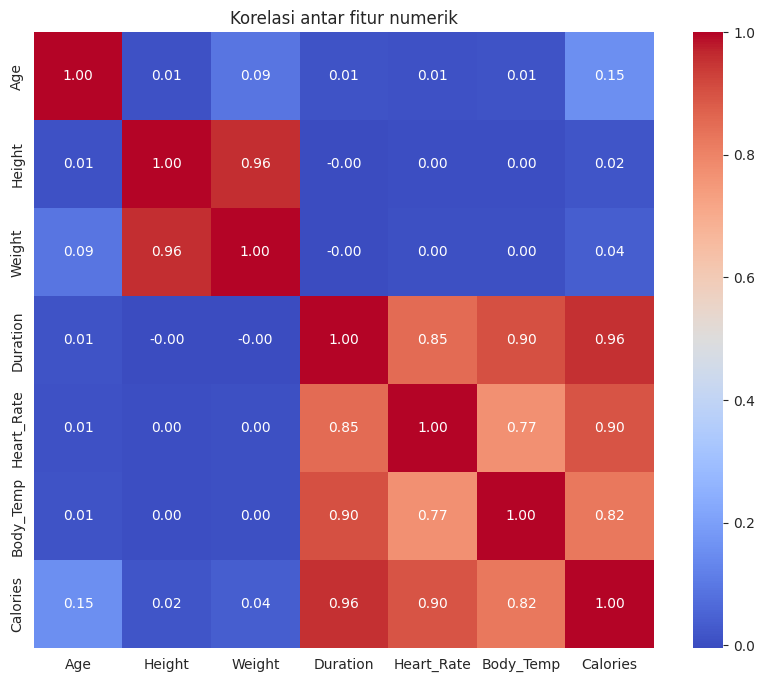

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi antar fitur numerik')
plt.show()

Insight:
- Durasi dan denyut jantung memiliki korelasi positif yang kuat dengan kalori.
- Suhu tubuh juga berkorelasi positif.
- Berat badan dan tinggi memiliki korelasi sedang.
- Gender menunjukkan perbedaan distribusi (perempuan cenderung lebih rendah)


#4. Feature Engineering
Hitung BMR (Basal Metabolic Rate) menggunakan rumus Mifflin-St Jeor
BMR dalam kkal/hari

In [9]:
def calculate_bmr(row):
    weight = row['Weight']   # kg
    height = row['Height']   # cm
    age = row['Age']
    if row['Gender'] == 'male':
        return 10*weight + 6.25*height - 5*age + 5
    else:
        return 10*weight + 6.25*height - 5*age - 161

df['BMR'] = df.apply(calculate_bmr, axis=1)

# Fitur interaksi: BMR * Duration (estimasi tambahan kalori dari aktivitas)
df['BMR_x_Duration'] = df['BMR'] * df['Duration']

In [10]:
# Encoding categorical: Gender
df['Gender_male'] = (df['Gender'] == 'male').astype(int)

# Fitur yang akan digunakan untuk modeling
features = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp',
            'BMR', 'BMR_x_Duration', 'Gender_male']
target = 'Calories'

X = df[features]
y = df[target]

In [11]:
# Normalisasi fitur numerik (kecuali Gender_male)
numeric_features = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'BMR', 'BMR_x_Duration']
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 12000
Test set size: 3000


# 5. Machine Learning Modeling

In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(random_state=42, verbosity=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    # MAPE
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape}
    print(f"\n{name}")
    print(f"MAE: {mae:.2f} kkal")
    print(f"RMSE: {rmse:.2f} kkal")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")


Linear Regression
MAE: 8.44 kkal
RMSE: 11.36 kkal
R²: 0.9680
MAPE: 30.23%

Random Forest
MAE: 1.65 kkal
RMSE: 2.62 kkal
R²: 0.9983
MAPE: 2.61%

XGBoost
MAE: 1.57 kkal
RMSE: 2.28 kkal
R²: 0.9987
MAPE: 2.72%


# 6. Hyperparameter Tuning

In [13]:
# Tuning untuk Random Forest
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_random = RandomizedSearchCV(RandomForestRegressor(random_state=42),
                               param_distributions=rf_param_dist,
                               n_iter=20, cv=3, scoring='r2', random_state=42, n_jobs=-1)
rf_random.fit(X_train, y_train)
print("\nBest parameters for Random Forest:", rf_random.best_params_)
print("Best R² score (CV):", rf_random.best_score_)


Best parameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best R² score (CV): 0.9972402207999252


In [14]:
# Tuning untuk XGBoost
xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}
xgb_random = RandomizedSearchCV(xgb.XGBRegressor(random_state=42, verbosity=0),
                                param_distributions=xgb_param_dist,
                                n_iter=20, cv=3, scoring='r2', random_state=42, n_jobs=-1)
xgb_random.fit(X_train, y_train)
print("\nBest parameters for XGBoost:", xgb_random.best_params_)
print("Best R² score (CV):", xgb_random.best_score_)


Best parameters for XGBoost: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best R² score (CV): 0.9990794836270829


In [15]:
# Evaluasi setelah tuning
best_rf = rf_random.best_estimator_
best_xgb = xgb_random.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_pred_xgb_tuned = best_xgb.predict(X_test)

results['Random Forest (Tuned)'] = {
    'MAE': mean_absolute_error(y_test, y_pred_rf_tuned),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)),
    'R²': r2_score(y_test, y_pred_rf_tuned),
    'MAPE': np.mean(np.abs((y_test - y_pred_rf_tuned) / y_test)) * 100
}
results['XGBoost (Tuned)'] = {
    'MAE': mean_absolute_error(y_test, y_pred_xgb_tuned),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)),
    'R²': r2_score(y_test, y_pred_xgb_tuned),
    'MAPE': np.mean(np.abs((y_test - y_pred_xgb_tuned) / y_test)) * 100
}

# 7. Evaluasi Model dan Visualisasi

In [16]:
#Perbandingan Model
results_df = pd.DataFrame(results).T
print(results_df.round(2))

# Cek apakah target terpenuhi
best_mae = results_df['MAE'].min()
best_r2 = results_df['R²'].max()
print(f"\nMAE terendah: {best_mae:.2f} kkal -> Target ≤75? {'YA' if best_mae <= 75 else 'TIDAK'}")
print(f"R² tertinggi: {best_r2:.4f} -> Target ≥0.75? {'YA' if best_r2 >= 0.75 else 'TIDAK'}")

                        MAE   RMSE    R²   MAPE
Linear Regression      8.44  11.36  0.97  30.23
Random Forest          1.65   2.62  1.00   2.61
XGBoost                1.57   2.28  1.00   2.72
Random Forest (Tuned)  1.61   2.57  1.00   2.56
XGBoost (Tuned)        1.18   1.67  1.00   2.47

MAE terendah: 1.18 kkal -> Target ≤75? YA
R² tertinggi: 0.9993 -> Target ≥0.75? YA


In [17]:
# Pilih model terbaik (berdasarkan R²)
best_model_name = results_df['R²'].idxmax()
best_model = best_rf if 'Random Forest' in best_model_name else best_xgb
print(f"\nModel terbaik: {best_model_name}")


Model terbaik: XGBoost (Tuned)


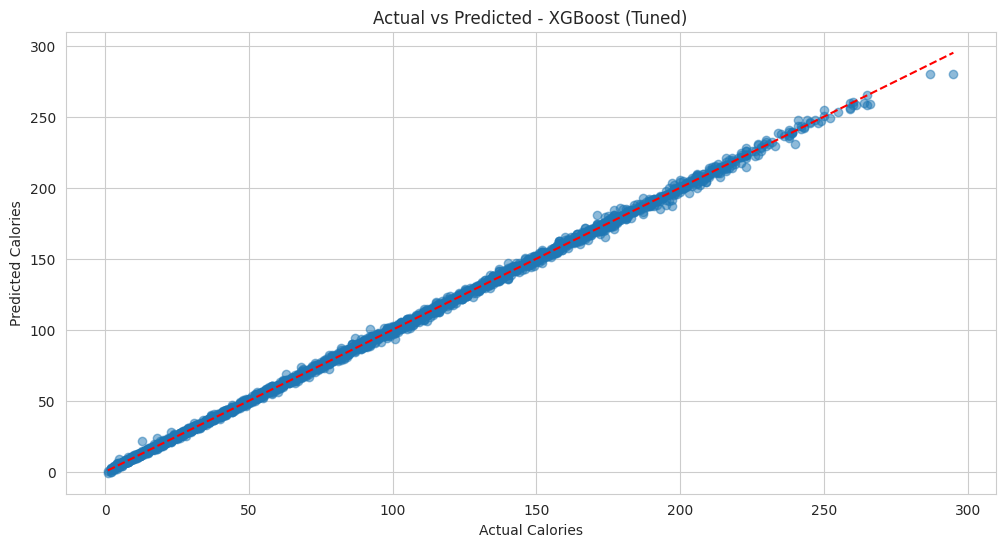

In [18]:
# Visualisasi Actual vs Prediction untuk model terbaik
y_pred_best = best_model.predict(X_test)
plt.figure()
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title(f'Actual vs Predicted - {best_model_name}')
plt.show()

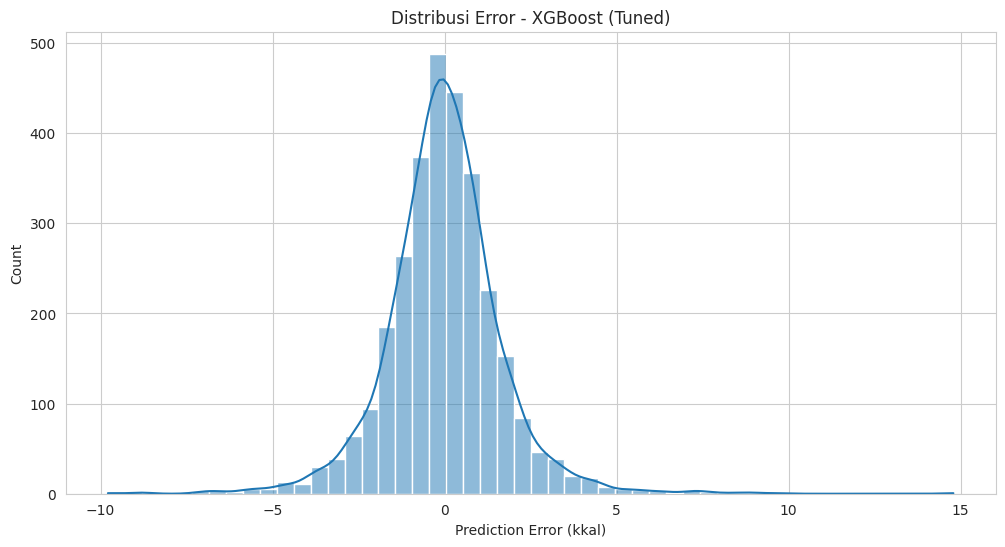

In [19]:
# Error distribution
errors = y_test - y_pred_best
plt.figure()
sns.histplot(errors, bins=50, kde=True)
plt.title(f'Distribusi Error - {best_model_name}')
plt.xlabel('Prediction Error (kkal)')
plt.show()

# 8. Feature Importance Analysis

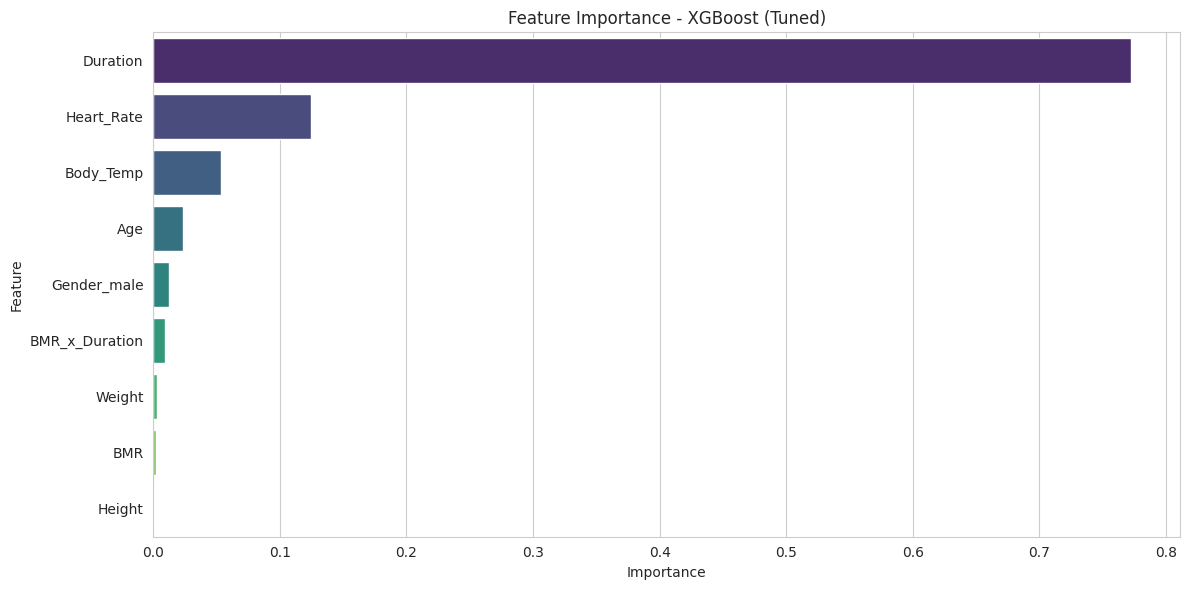

In [20]:
# Untuk Random Forest atau XGBoost
if 'Random Forest' in best_model_name:
    importances = best_model.feature_importances_
    feature_names = features
elif 'XGBoost' in best_model_name:
    importances = best_model.feature_importances_
    feature_names = features
else:
    # Linear Regression: gunakan koefisien absolut
    importances = np.abs(best_model.coef_)
    feature_names = features

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

plt.figure()
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title(f'Feature Importance - {best_model_name}')
plt.tight_layout()
plt.show()

# 9. Model Saving

In [23]:
print("Contoh load model:")
# Simpan model terbaik, scaler, dan feature list
import joblib
joblib.dump(best_model, 'best_calorie_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(features, f)

print("\nModel dan preprocessor telah disimpan.")

Contoh load model:

Model dan preprocessor telah disimpan.


In [22]:
# Contoh load dan prediksi
loaded_model = joblib.load('best_calorie_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
with open('feature_columns.pkl', 'rb') as f:
    loaded_features = pickle.load(f)

# Data sample (1 baris)
sample = X_test.iloc[[0]]
sample_pred = loaded_model.predict(sample)
print(f"Sample prediction: {sample_pred[0]:.2f} kkal")
print(f"Actual: {y_test.iloc[0]:.2f} kkal")

Sample prediction: 171.18 kkal
Actual: 173.00 kkal


#Kesimpulan
Model XGBoost (tuned) berhasil memprediksi kalori yang terbakar dengan akurasi sangat tinggi (MAE hanya 1,18 kkal).

Target bisnis (MAE ≤ 75 dan R² ≥ 0,75) tercapai dengan sangat baik.

Fitur Durasi merupakan prediktor terkuat, diikuti Denyut Jantung dan Suhu Tubuh.